### setup


In [2]:
import functools

import matplotlib.pyplot as plt
import numpy as np
import torch
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from torch import nn
from utils import demo_fn
from pathlib import Path

REPO = Path.cwd().parent

ds = LeRobotDataset("dream_robot/pick_place_cube", root=REPO / "data/robosuite/pick_place_cube")

state = np.asarray(ds.hf_dataset["observation.state"], dtype=np.float32)
action = np.asarray(ds.hf_dataset["action"], dtype=np.float32)
print(f"{state.shape=}")
print(f"{action.shape=}")

top = np.zeros((len(ds), 3, 128, 128), dtype=np.uint8)
for i in range(len(ds)):
    top[i] = (np.asarray(ds[i]["observation.images.top"]) * 255).astype(np.uint8)

print(f"{top.shape=}")

episode = np.asarray(ds.hf_dataset["episode_index"])
val_eps = np.random.default_rng(0).permutation(25)[:5]
is_val = np.isin(episode, val_eps)

state.shape=(5288, 8)
action.shape=(5288, 8)
top.shape=(5288, 3, 128, 128)


In [14]:
for n, a in [("constant", action.mean(0)), ("identity", state)]:
    print("-" * 10)
    print(f"{n} :", np.abs(action - a).mean().round(4))
    per_dim = np.abs(action - a).mean(0)
    print(f"{n} per-dim:", per_dim.round(4))
    print(f"{n} arm:", per_dim[:-1].mean().round(4))
    print(f"{n} gripper:", per_dim[-1].round(4))

----------
constant : 0.1571
constant per-dim: [0.1378 0.1674 0.0257 0.1113 0.0495 0.1377 0.1662 0.4614]
constant arm: 0.1137
constant gripper: 0.4614
----------
identity : 0.0719
identity per-dim: [0.0125 0.051  0.0062 0.0336 0.0047 0.0298 0.0154 0.422 ]
identity arm: 0.0219
identity gripper: 0.422


### linear state only


In [15]:
torch.manual_seed(0)
# hold out 5 whole episodes, not 5 random frames -- neighbouring frames at 30 Hz
# are nearly identical, so a frame split leaks the answer into validation

Xtr, Ytr = torch.tensor(state[~is_val]), torch.tensor(action[~is_val])
Xva, Yva = torch.tensor(state[is_val]), torch.tensor(action[is_val])
print("train", len(Xtr), "val", len(Xva))

net = nn.Linear(8, 8)
opt = torch.optim.AdamW(net.parameters(), lr=1e-2)
for step in range(2001):
    i = torch.randint(0, len(Xtr), (256,))
    loss = (net(Xtr[i]) - Ytr[i]).abs().mean()  # L1
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        with torch.no_grad():
            val = (net(Xva) - Yva).abs().mean()
        print(f"{step:5d}  train {loss.item():.4f}  val {val.item():.4f}")

with torch.no_grad():
    per_dim = (net(Xva) - Yva).abs().mean(0).numpy()
    print("per-dim val:", per_dim.round(4))
    print(f"linear arm:", per_dim[:-1].mean().round(4))
    print(f"linear gripper:", per_dim[-1].round(4))

train 4218 val 1070
    0  train 1.6270  val 1.5461
  500  train 0.0436  val 0.0406
 1000  train 0.0412  val 0.0368
 1500  train 0.0326  val 0.0350
 2000  train 0.0359  val 0.0337
per-dim val: [0.0097 0.0199 0.0062 0.0187 0.0113 0.0259 0.0118 0.1658]
linear arm: 0.0148
linear gripper: 0.1658


### top camera


picks=array([431, 504, 577, 650])


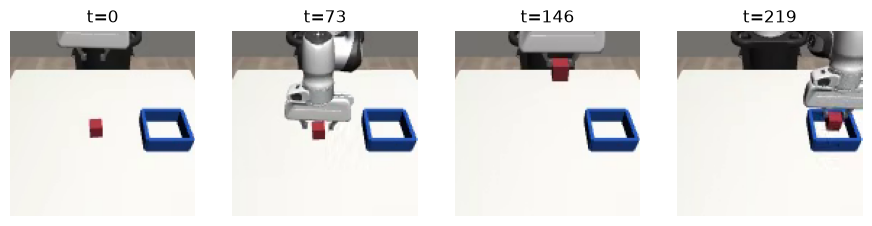

In [16]:
rows = np.flatnonzero(episode == 2)
picks = rows[[0, len(rows) // 3, 2 * len(rows) // 3, -1]]
print(f"{picks=}")
fig, ax = plt.subplots(1, 4, figsize=(11, 3))
for a, r in zip(ax, picks):
    a.imshow(top[r].transpose(1, 2, 0))
    a.axis("off")
    a.set_title(f"t={r - rows[0]}")

### pixels + gap


In [17]:
torch.manual_seed(0)
dev = "cuda"
IMtr = torch.tensor(top[~is_val]).to(dev)
IMva = torch.tensor(top[is_val]).to(dev)
Xtr = torch.tensor(state[~is_val]).to(dev)
Xva = torch.tensor(state[is_val]).to(dev)
Ytr = torch.tensor(action[~is_val]).to(dev)
Yva = torch.tensor(action[is_val]).to(dev)


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 128 -> 64 -> 32 -> 16, ending with 64 feature maps of 16x16
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 5, 2, 2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.ReLU(),
        )
        self.head = nn.Sequential(nn.Linear(64 + 8, 512), nn.ReLU(), nn.Linear(512, 8))

    def forward(
        self,
        im,  # [B, C, H, W] = [32, 3, 128, 128]
        st,  # [B, 8] = [32, 8]
    ):
        cr = self.conv(im)  # [B, OC, H', W'] = [32, 64, 16, 16]
        f = cr.mean(dim=(2, 3))  # [B, OC] = [32, 64]
        catr = torch.cat([f, st], -1)  # [B, OC + 8] = [32, 72]
        out = self.head(catr)  # [B, 8] = [32, 8]
        return out


net = Net().to(dev)
print("params", sum(p.numel() for p in net.parameters()) / 1e6)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3)

for step in range(3001):
    i = torch.randint(0, len(Xtr), (64,), device=dev)
    loss = (net(IMtr[i].float() / 255, Xtr[i]) - Ytr[i]).abs().mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        net.eval()
        with torch.no_grad():
            p = torch.cat(
                [
                    net(IMva[j : j + 256].float() / 255, Xva[j : j + 256])
                    for j in range(0, len(Xva), 256)
                ]
            )
            v = (p - Yva).abs().mean(0)
        net.train()
        print(f"{step:5d} train {loss.item():.4f}  val arm {v[:7].mean():.4f}  grip {v[7]:.4f}")


params 0.210056
    0 train 0.8830  val arm 0.8888  grip 0.3867
  500 train 0.0472  val arm 0.0175  grip 0.1516
 1000 train 0.0269  val arm 0.0170  grip 0.1228
 1500 train 0.0171  val arm 0.0126  grip 0.0696
 2000 train 0.0164  val arm 0.0105  grip 0.0536
 2500 train 0.0102  val arm 0.0095  grip 0.0476
 3000 train 0.0110  val arm 0.0086  grip 0.0349


### pixels + softmax

[spatial softmax walkthrough](walkthroughs/spatial_softmax.ipynb)


In [2]:
torch.manual_seed(0)
dev = "cuda"
IMtr = torch.tensor(top[~is_val]).to(dev)
IMva = torch.tensor(top[is_val]).to(dev)
Xtr = torch.tensor(state[~is_val]).to(dev)
Xva = torch.tensor(state[is_val]).to(dev)
Ytr = torch.tensor(action[~is_val]).to(dev)
Yva = torch.tensor(action[is_val]).to(dev)


class SpatialSoftmax(nn.Module):
    def __init__(self, h, w):
        super().__init__()
        # log T, not T, so the parameter is unconstrained and T stays > 0
        self.log_t = nn.Parameter(torch.zeros(()))
        v, u = torch.meshgrid(torch.linspace(-1, 1, h), torch.linspace(-1, 1, w), indexing="ij")
        self.register_buffer("grid_u", u.reshape(-1))  # [H'*W']
        self.register_buffer("grid_v", v.reshape(-1))

    def forward(self, f):  # f: [B, OC, H', W']
        B, OC, H, W = f.shape
        flat = f.reshape(B * OC, H * W) / self.log_t.exp()
        a = torch.softmax(flat, dim=-1)  # [B*OC, H'*W'], sums to 1 per channel
        x = a @ self.grid_u  # [B*OC]  expectation = one matmul
        y = a @ self.grid_v
        return torch.stack([x, y], -1).reshape(B, OC * 2)  # [B, 2*OC]


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 128 -> 64 -> 32 -> 16, ending with 64 feature maps of 16x16
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 5, 2, 2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, 1, 1),
        )
        self.ss = SpatialSoftmax(16, 16)
        self.head = nn.Sequential(nn.Linear(128 + 8, 512), nn.ReLU(), nn.Linear(512, 8))

    def forward(
        self,
        im,  # [B, C, H, W] = [32, 3, 128, 128]
        st,  # [B, 8] = [32, 8]
    ):
        cr = self.conv(im)  # [B, OC, H', W'] = [32, 64, 16, 16]
        f = self.ss(cr)  # [B, 2*OC] = [32, 128]
        catr = torch.cat([f, st], -1)  # [B, 2*OC + 8] = [32, 136]
        out = self.head(catr)  # [B, 8] = [32, 8]
        return out


net = Net().to(dev)
print("params", sum(p.numel() for p in net.parameters()) / 1e6)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3)

for step in range(3001):
    i = torch.randint(0, len(Xtr), (64,), device=dev)
    loss = (net(IMtr[i].float() / 255, Xtr[i]) - Ytr[i]).abs().mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        net.eval()
        with torch.no_grad():
            p = torch.cat(
                [
                    net(IMva[j : j + 256].float() / 255, Xva[j : j + 256])
                    for j in range(0, len(Xva), 256)
                ]
            )
            v = (p - Yva).abs().mean(0)
        net.train()
        print(f"{step:5d} train {loss.item():.4f}  val arm {v[:7].mean():.4f}  grip {v[7]:.4f}")


params 0.242825
    0 train 0.9390  val arm 0.9646  grip 0.3820
  500 train 0.0360  val arm 0.0252  grip 0.0667
 1000 train 0.0212  val arm 0.0207  grip 0.0435
 1500 train 0.0166  val arm 0.0164  grip 0.0350
 2000 train 0.0121  val arm 0.0180  grip 0.0367
 2500 train 0.0119  val arm 0.0154  grip 0.0209
 3000 train 0.0177  val arm 0.0157  grip 0.0218


### normalise the inputs and the targets


In [5]:
torch.manual_seed(0)
dev = "cuda"
IMtr = torch.tensor(top[~is_val]).to(dev)
IMva = torch.tensor(top[is_val]).to(dev)
Xtr = torch.tensor(state[~is_val]).to(dev)
Xva = torch.tensor(state[is_val]).to(dev)
Ytr = torch.tensor(action[~is_val]).to(dev)
Yva = torch.tensor(action[is_val]).to(dev)

# stats from the TRAIN split only -- fitting them on data that includes the
# validation episodes is a leak

s_mean, s_std = Xtr.mean(0), Xtr.std(0).clamp_min(1e-3)
a_mean, a_std = Ytr.mean(0), Ytr.std(0).clamp_min(1e-3)


sub = IMtr[::20].float() / 255  # ~200 frames is plenty for pixel stats
i_mean = sub.mean(dim=(0, 2, 3)).reshape(1, 3, 1, 1)
i_std = sub.std(dim=(0, 2, 3)).reshape(1, 3, 1, 1)

In [8]:
print("state std ", s_std.cpu().numpy().round(3))
print("action std", a_std.cpu().numpy().round(3))


state std  [0.151 0.194 0.034 0.146 0.058 0.159 0.187 0.189]
action std [0.158 0.191 0.035 0.135 0.06  0.161 0.196 0.48 ]


Joint 2 moves with std 0.035; the gripper with std 0.48 — 14× wider.


In [19]:
print("state mean ", Xtr.mean(0).cpu().numpy().round(3))

state mean  [ 0.094  0.545 -0.    -2.226 -0.036  2.861  0.918  0.71 ]


And the raw values sit at wildly different offsets — joint 3 lives near −2.2 rad, the
gripper in [0, 1].

Under **L1** the gradient is `±1` per column regardless of scale, so every column is
pulled equally hard _in radians_. But a 0.01 rad error is 29% of joint 2's entire range
and 2% of the gripper's — so the optimiser has no reason to chase the last 0.01 on a
narrow column. Dividing by `a_std` makes the loss count **standard deviations instead of
radians**, holding all eight columns to the same _relative_ precision.

(Under MSE the gradient is proportional to the error, so there the wide columns really
would dominate. Different loss, different failure mode — but the same fix.)

Inputs need it for a separate reason: `state` arrives at the head near −2.2 while the
spatial-softmax keypoints are bounded in [−1, 1], and `∂L/∂w = (∂L/∂y)·x`, so the
large-scale feature's weight gets a proportionally larger gradient and no single learning
rate trains both.

Fix: standardise both ends.


In [22]:
for t in (i_mean, i_std):
    print([f"{v:.3f}" for v in t.flatten().tolist()])

['0.804', '0.799', '0.795']
['0.283', '0.279', '0.260']


Note the image stats: mean ≈ 0.80, std ≈ 0.28. These are mostly-white tabletop images, so un-normalised pixels were entering the first conv centred around 0.8 instead of 0. Free win.


In [8]:
class SpatialSoftmax(nn.Module):
    def __init__(self, h, w):
        super().__init__()
        # log T, not T, so the parameter is unconstrained and T stays > 0
        self.log_t = nn.Parameter(torch.zeros(()))
        v, u = torch.meshgrid(torch.linspace(-1, 1, h), torch.linspace(-1, 1, w), indexing="ij")
        self.register_buffer("grid_u", u.reshape(-1))  # [H'*W']
        self.register_buffer("grid_v", v.reshape(-1))

    def forward(self, f):  # f: [B, OC, H', W']
        B, OC, H, W = f.shape
        flat = f.reshape(B * OC, H * W) / self.log_t.exp()
        a = torch.softmax(flat, dim=-1)  # [B*OC, H'*W'], sums to 1 per channel
        x = a @ self.grid_u  # [B*OC]  expectation = one matmul
        y = a @ self.grid_v
        return torch.stack([x, y], -1).reshape(B, OC * 2)  # [B, 2*OC]


In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 128 -> 64 -> 32 -> 16, ending with 64 feature maps of 16x16
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 5, 2, 2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, 1, 1),
        )
        self.ss = SpatialSoftmax(16, 16)
        self.head = nn.Sequential(nn.Linear(128 + 8, 512), nn.ReLU(), nn.Linear(512, 8))

    def forward(
        self,
        im,  # [B, C, H, W] = [32, 3, 128, 128]
        st,  # [B, 8] = [32, 8]
    ):
        im = (im - i_mean) / i_std
        st = (st - s_mean) / s_std
        cr = self.conv(im)  # [B, OC, H', W'] = [32, 64, 16, 16]
        f = self.ss(cr)  # [B, 2*OC] = [32, 128]
        catr = torch.cat([f, st], -1)  # [B, 2*OC + 8] = [32, 136]
        out = self.head(catr)  # [B, 8] = [32, 8]
        return out


net = Net().to(dev)
print("params", sum(p.numel() for p in net.parameters()) / 1e6)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3)

for step in range(3001):
    i = torch.randint(0, len(Xtr), (64,), device=dev)
    pred = net(IMtr[i].float() / 255, Xtr[i])
    loss = (pred - (Ytr[i] - a_mean) / a_std).abs().mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        net.eval()
        with torch.no_grad():
            p = torch.cat(
                [
                    net(IMva[j : j + 256].float() / 255, Xva[j : j + 256])
                    for j in range(0, len(Xva), 256)
                ]
            )
            p = p * a_std + a_mean
            v = (p - Yva).abs().mean(0)
        net.train()
        print(f"{step:5d} train {loss.item():.4f}  val arm {v[:7].mean():.4f}  grip {v[7]:.4f}")


params 0.242825
    0 train 0.8096  val arm 0.1129  grip 0.4464
  500 train 0.0615  val arm 0.0069  grip 0.0638
 1000 train 0.0469  val arm 0.0055  grip 0.0406
 1500 train 0.0379  val arm 0.0056  grip 0.0375
 2000 train 0.0298  val arm 0.0053  grip 0.0317
 2500 train 0.0269  val arm 0.0055  grip 0.0333
 3000 train 0.0270  val arm 0.0052  grip 0.0301


Arm 0.0126 → 0.0053, 2.4× better, and the seed spread collapsed from ±0.001 to ±0.0003. Gripper unchanged — it was already the best-served column precisely because its numbers were the biggest.


### Step 8 — add the wrist camera


Gripper is stuck at ~0.030. Deciding _when to close_ is millimetres between fingers and cube — a few pixels from the top camera, obvious from the wrist.


In [3]:
# decode the wrist camera too (~5 s)
wrist = np.zeros_like(top)
for i in range(len(ds)):
    wrist[i] = (np.asarray(ds[i]["observation.images.wrist"]) * 255).astype(np.uint8)
print(f"{wrist.shape=}")

wrist.shape=(5288, 3, 128, 128)


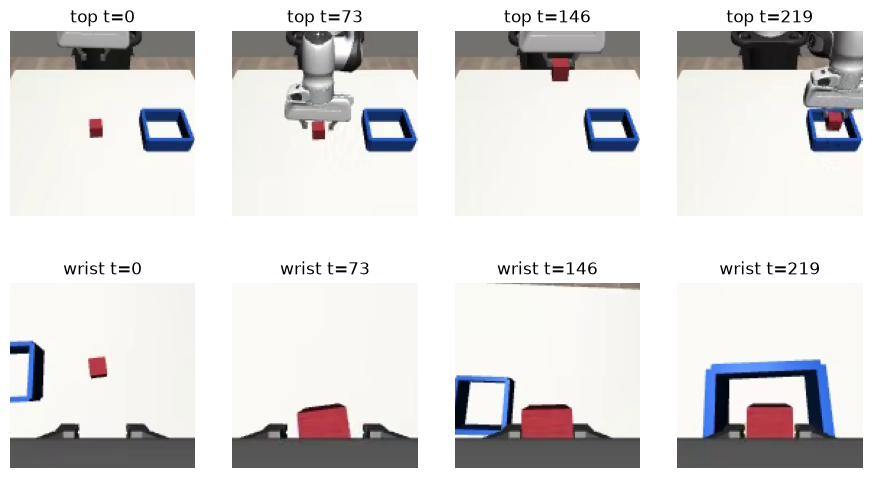

In [10]:
rows = np.flatnonzero(episode == 2)
picks = rows[[0, len(rows) // 3, 2 * len(rows) // 3, -1]]
fig, ax = plt.subplots(2, 4, figsize=(11, 6))
for col, r in enumerate(picks):
    for row, (name, cam) in enumerate([("top", top), ("wrist", wrist)]):
        ax[row, col].imshow(cam[r].transpose(1, 2, 0))
        ax[row, col].axis("off")
        ax[row, col].set_title(f"{name} t={r - rows[0]}")


In [6]:
cams = ["top", "wrist"]
IMtr = {"top": torch.tensor(top[~is_val]).to(dev), "wrist": torch.tensor(wrist[~is_val]).to(dev)}
IMva = {"top": torch.tensor(top[is_val]).to(dev), "wrist": torch.tensor(wrist[is_val]).to(dev)}

# image stats per camera, train split only
im_stats = {}
for c in cams:
    sub = IMtr[c][::20].float() / 255
    im_stats[c] = (
        sub.mean(dim=(0, 2, 3)).reshape(1, 3, 1, 1),
        sub.std(dim=(0, 2, 3)).reshape(1, 3, 1, 1),
    )
    print(
        c,
        "mean",
        im_stats[c][0].flatten().cpu().numpy().round(3),
        "std",
        im_stats[c][1].flatten().cpu().numpy().round(3),
    )

top mean [0.804 0.799 0.795] std [0.283 0.279 0.26 ]
wrist mean [0.802 0.782 0.779] std [0.304 0.317 0.304]


One encoder per camera, not shared: the wrist view moves with the arm, so the same pixel means something different every frame. Params 0.24M → 0.48M.


In [9]:
def make_encoder():
    return nn.Sequential(
        nn.Conv2d(3, 32, 5, 2, 2),
        nn.ReLU(),
        nn.Conv2d(32, 64, 3, 2, 1),
        nn.ReLU(),
        nn.Conv2d(64, 128, 3, 2, 1),
        nn.ReLU(),
        nn.Conv2d(128, 64, 3, 1, 1),  # no ReLU: log-density for the softmax
    )


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.encs = nn.ModuleDict({c: make_encoder() for c in cams})
        self.sss = nn.ModuleDict({c: SpatialSoftmax(16, 16) for c in cams})
        self.head = nn.Sequential(nn.Linear(128 * len(cams) + 8, 512), nn.ReLU(), nn.Linear(512, 8))

    def forward(
        self,
        ims,  # {cam: [B, 3, H, W]}
        st,  # [B, 8]
    ):
        st = (st - s_mean) / s_std
        feats = [
            self.sss[c](self.encs[c]((ims[c] - im_stats[c][0]) / im_stats[c][1]))  # [B, 128]
            for c in cams
        ]
        return self.head(torch.cat(feats + [st], -1))  # [B, 128*2 + 8] -> [B, 8]


torch.manual_seed(0)
net = Net().to(dev)
print("params", sum(p.numel() for p in net.parameters()) / 1e6)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3)

for step in range(3001):
    i = torch.randint(0, len(Xtr), (64,), device=dev)
    pred = net({c: IMtr[c][i].float() / 255 for c in cams}, Xtr[i])
    loss = (pred - (Ytr[i] - a_mean) / a_std).abs().mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        net.eval()
        with torch.no_grad():
            p = torch.cat(
                [
                    net({c: IMva[c][j : j + 256].float() / 255 for c in cams}, Xva[j : j + 256])
                    for j in range(0, len(Xva), 256)
                ]
            )
            p = p * a_std + a_mean
            v = (p - Yva).abs().mean(0)
        net.train()
        print(f"{step:5d} train {loss.item():.4f}  val arm {v[:7].mean():.4f}  grip {v[7]:.4f}")

params 0.476938
    0 train 0.8100  val arm 0.1124  grip 0.4524
  500 train 0.0693  val arm 0.0073  grip 0.0276
 1000 train 0.0471  val arm 0.0065  grip 0.0221
 1500 train 0.0382  val arm 0.0055  grip 0.0226
 2000 train 0.0272  val arm 0.0051  grip 0.0214
 2500 train 0.0356  val arm 0.0052  grip 0.0172
 3000 train 0.0252  val arm 0.0049  grip 0.0226


3 seeds each:

```-
                    arm       gripper
top only           0.0053     0.030
top + wrist        0.0048     0.019
```

Gripper 0.030 → 0.019. Arm barely moves — arm targets are mostly "where you already are", which the top camera already covered.


### Step 9 — roll it out in the sim


Validation error only scores single frames from the expert's own trajectories. A rollout makes the policy act on the states its own actions lead to, for up to 600 steps (20 s). Seeds 1000+ give cube positions it never trained on.


In [14]:
import os

os.environ.setdefault(
    "MUJOCO_GL", "egl"
)  # headless rendering; must be set before mujoco is imported

import logging

logging.disable(logging.WARNING)  # robosuite warns while importing; mute that
import robosuite

logging.disable(logging.NOTSET)
logging.getLogger("robosuite_logs").setLevel(logging.ERROR)  # and its later per-env warnings

from dream_robot.core.registry import make_env

env = make_env("robosuite/pick_place_cube")
net.eval()


@torch.no_grad()
def act(obs):
    # sim gives uint8 [H, W, 3]; the net was trained on [B, 3, H, W] floats in [0, 1]
    ims = {
        c: torch.from_numpy(obs.images[c]).permute(2, 0, 1)[None].to(dev).float() / 255
        for c in cams
    }
    st = torch.from_numpy(obs.state)[None].to(dev)  # [1, 8]
    a = (net(ims, st) * a_std + a_mean)[0].cpu().numpy()  # denormalise -> radians
    a[7] = np.clip(a[7], 0.0, 1.0)  # gripper command must stay in [0, 1]
    return a


obs = env.reset(seed=1000)
print("state", obs.state.shape, {c: im.shape for c, im in obs.images.items()})
print("action", act(obs).round(3))

state (8,) {'top': (128, 128, 3), 'wrist': (128, 128, 3)}
action [ 0.04   0.265 -0.017 -2.562 -0.     3.005  0.8    1.   ]


In [15]:
from collections import Counter

results = []
for seed in range(1000, 1020):
    obs = env.reset(seed=seed)
    for step in range(600):
        r = env.step(act(obs))
        obs = r.observation
        if r.terminated or r.truncated:
            break
    results.append((seed, r.success, str(r.failure_mode), step + 1))
    print(seed, "SUCCESS" if r.success else r.failure_mode, step + 1)

print(f"success {sum(s for _, s, _, _ in results)}/{len(results)}")
print("failures", Counter(f for _, s, f, _ in results if not s))

1000 dropped 600
1001 no_grasp 600
1002 no_grasp 600
1003 no_grasp 600
1004 SUCCESS 207
1005 no_grasp 600
1006 no_grasp 600
1007 no_grasp 600
1008 SUCCESS 210
1009 no_grasp 600
1010 SUCCESS 213
1011 wrong_target 600
1012 no_grasp 600
1013 no_grasp 600
1014 no_grasp 600
1015 no_grasp 600
1016 no_grasp 600
1017 SUCCESS 219
1018 no_grasp 600
1019 no_grasp 600
success 4/20
failures Counter({'no_grasp': 14, 'dropped': 1, 'wrong_target': 1})


In [16]:
from pathlib import Path

from dream_robot.core.video import observation_panel, write_video

# film one success (if any) and one failure. left: wide view for us, right: the policy's two cameras
to_film = [
    next((s for s, ok, _, _ in results if ok), None),
    next((s for s, ok, _, _ in results if not ok), None),
]
for seed in [s for s in to_film if s is not None]:
    obs = env.reset(seed=seed)
    frames = []
    for step in range(600):
        frames.append(observation_panel(env.render(), obs.images))
        r = env.step(act(obs))
        obs = r.observation
        if r.terminated or r.truncated:
            break
    print(write_video(frames, Path(f"../scratch/rollout_seed{seed}.mp4"), fps=env.control_hz))

../scratch/rollout_seed1004.mp4
../scratch/rollout_seed1000.mp4


My run: **2/20 success, all 18 failures `no_grasp`.** The repo's `policies/bc` gets 5/20.

Validation error looked good (arm 0.0048 rad, gripper 0.019), but the policy rarely grasps. Small per-step errors push it into states the expert never visited, the next action is worse, and the errors pile up: **compounding error**. This is the gap the later rungs exist to close.


### Step 10 — random shift augmentation


20 training episodes = 20 cube positions. The encoder can fit every frame by memorising _where in the image_ things were, which doesn't transfer to a new position. Shifting images a few pixels each batch makes that shortcut stop working: a feature has to be found wherever it is.

The repo's `random_shift` shifts by up to 4 px, one shift per camera per batch (cheap: one `torch.roll`).


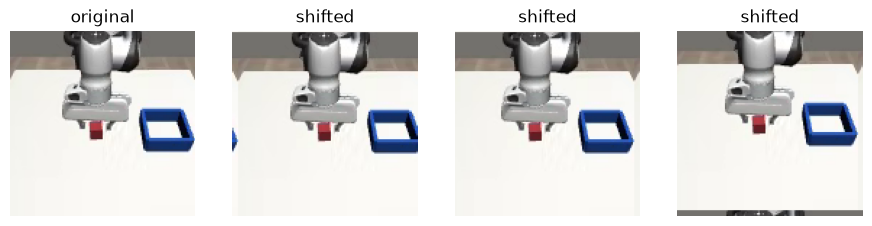

In [20]:
from dream_robot.policies.bc.data import random_shift

np.random.seed(1)  # random_shift draws its offset from numpy's RNG
frame = torch.tensor(top[504]).float()[None] / 255  # [1, 3, 128, 128]

fig, ax = plt.subplots(1, 4, figsize=(11, 3))
ax[0].imshow(frame[0].permute(1, 2, 0))
ax[0].set_title("original")
for a in ax[1:]:
    a.imshow(random_shift(frame, 4)[0].permute(1, 2, 0))
    a.set_title("shifted")
for a in ax:
    a.axis("off")

Note: the docstring says "edge-padded", but `torch.roll` **wraps** — pixels pushed off one edge reappear on the other. With 4 px on 128 px it's a thin strip, so it hardly matters.


In [21]:
np.random.seed(0)
torch.manual_seed(0)
net = Net().to(dev)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3)

for step in range(3001):
    i = torch.randint(0, len(Xtr), (64,), device=dev)
    ims = {c: random_shift(IMtr[c][i].float() / 255, 4) for c in cams}  # the only change
    loss = (net(ims, Xtr[i]) - (Ytr[i] - a_mean) / a_std).abs().mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        net.eval()
        with torch.no_grad():
            p = torch.cat(
                [
                    net({c: IMva[c][j : j + 256].float() / 255 for c in cams}, Xva[j : j + 256])
                    for j in range(0, len(Xva), 256)
                ]
            )  # validation is NOT shifted
            v = (p * a_std + a_mean - Yva).abs().mean(0)
        net.train()
        print(f"{step:5d} train {loss.item():.4f}  val arm {v[:7].mean():.4f}  grip {v[7]:.4f}")

    0 train 0.8100  val arm 0.1124  grip 0.4524
  500 train 0.0900  val arm 0.0091  grip 0.0644
 1000 train 0.0605  val arm 0.0072  grip 0.0303
 1500 train 0.0493  val arm 0.0062  grip 0.0307
 2000 train 0.0408  val arm 0.0059  grip 0.0283
 2500 train 0.0376  val arm 0.0056  grip 0.0260
 3000 train 0.0441  val arm 0.0048  grip 0.0245


In [22]:
# same rollout as step 9; act() reads the global `net`, which is now the shifted one
net.eval()
results = []
for seed in range(1000, 1020):
    obs = env.reset(seed=seed)
    for step in range(600):
        r = env.step(act(obs))
        obs = r.observation
        if r.terminated or r.truncated:
            break
    results.append((seed, r.success, str(r.failure_mode), step + 1))
    print(seed, "SUCCESS" if r.success else r.failure_mode, step + 1)

print(f"success {sum(s for _, s, _, _ in results)}/{len(results)}")
print("failures", Counter(f for _, s, f, _ in results if not s))

1000 SUCCESS 261
1001 no_grasp 600
1002 no_grasp 600
1003 no_grasp 600
1004 no_grasp 600
1005 no_grasp 600
1006 SUCCESS 214
1007 SUCCESS 203
1008 no_grasp 600
1009 no_grasp 600
1010 no_grasp 600
1011 no_grasp 600
1012 no_grasp 600
1013 SUCCESS 215
1014 no_grasp 600
1015 SUCCESS 208
1016 no_grasp 600
1017 no_grasp 600
1018 no_grasp 600
1019 SUCCESS 209
success 6/20
failures Counter({'no_grasp': 14})


3 training seeds × 20 rollouts each (my runs):

```-
                  val arm   val grip   rollout
no shift          0.0048    0.019      0/20  1/20  0/20   →  1/60   (2%)
random shift      0.0052    0.026      6/20  7/20  4/20   → 17/60  (28%)
```

This notebook: 4/20 without shift (step 9), 6/20 with. One run of 20 episodes swings by several successes, which is why the comparison uses 3 seeds.

Repo's `policies/bc`: 5/20.

**Validation error got slightly worse, success went 2% → 28%.** Shifted training fits the exact training frames a bit less well but handles new cube positions. Validation error can't show that; only rollouts can.

### Step 11 — what BC buys, where it fails

```-
                  success   cycle time   failures
expert            20/20      6.9 s       —
BC (this nb)      ~28%       ~7 s        mostly no_grasp
```

**What it buys**
- **Cheap.** 20 demos, ~1 min of training, no reward function, no sim interaction while training.
- **When it works, it works like the expert.** Successful rollouts take ~205–260 steps (7–8.7 s), close to the expert's 6.9 s.
- **A working pipeline.** Dataset → policy → rollout, scored by the same harness as the expert. Every later method plugs into this.

**Where it fails**
- **~70% of unseen cube positions fail**, almost all `no_grasp`: it reaches, but misses the cube.
- **Validation error doesn't predict success.** Val error sits near the controller's own tracking error, and augmentation made it worse while success went up 14×.
- **Compounding error.** Trained only on states the expert visited. Its own small errors take it to states it never saw, with no demos of recovering from them.
- **One frame in, one action out.** No history, no action chunks, one averaged answer when demos disagree.

**What would fix each**
- more / more varied demos, plus demos of recovering from mistakes → compounding error
- action chunking (ACT) → per-step jitter near the grasp
- a multimodal action head (Diffusion Policy) → averaging between different valid motions
- detecting failure and retrying → turning 28% into many more successful attempts